# Uruguay: Western- vs Non-Western-only catalog coverage over time

For every individual matched to *Oriental Republic of Uruguay* in Cliopatria,
we ask which side of the catalogue/Wikipedia world records them. We classify
every Wikidata catalog (`identifier_types.country_name`) and every Wikipedia
language edition as either **Western** or **non-Western**. Each individual
is then labelled:

* *Western only*  — appears only in Western catalogs / Wikipedias
* *Non-Western only* — appears only in non-Western catalogs / Wikipedias

We restrict to individuals whose birthdate is known with **year precision**
(`birthdate_precision >= 9`) so the temporal axis is meaningful, and we plot
the number of active individuals per decade for each group.

In [1]:
# === notebook config ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/humans_clean.duckdb'
POLITY = 'Oriental Republic of Uruguay'
MIN_PRECISION = 9   # 9 = year, 10 = month, 11 = day
BIN_SIZE = 10       # decade bins

FIGSIZE = (9, 5)
DPI = 140
COLOR_W = '#2171b5'
COLOR_NW = '#b5542a'

import matplotlib as _mpl
_mpl.rcParams.update({
    'figure.figsize': FIGSIZE,
    'figure.dpi': DPI,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

## 1. Classify catalogs and Wikipedia editions

Catalogs come from `identifier_types.country_name`. Wikipedia editions
are split by language code: roughly Western Europe / Anglosphere /
Latin Romance vs Slavic / Middle Eastern / Asian / African.

In [2]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

WESTERN_COUNTRIES = {
    'United States', 'Washington, D.C.', 'Germany', 'France', 'Poland',
    'Netherlands', 'Kingdom of the Netherlands', 'United Kingdom', 'Wales',
    'Italy', 'Kingdom of Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Faroe Islands', 'Austria', 'Belgium', 'Switzerland',
    'Portugal', 'Czech Republic', 'Slovakia', 'Greece', 'Hungary',
    'Ireland', 'Canada', 'Australia', 'New Zealand', 'Romania', 'Croatia',
    'Serbia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Bulgaria',
    'Iceland', 'Luxembourg', 'Liechtenstein', 'Andorra', 'Cyprus',
    'Vatican City', 'Weimar Republic', 'German Reich',
}

WESTERN_WIKI_LANGS = {
    'en','de','fr','es','it','pt','nl','pl','sv','no','nb','nn','fi','da',
    'is','fo','ga','gd','cy','kw','gv','br','co','oc','ca','eu','gl','ast',
    'an','ext','lad','mwl','rm','fur','lij','lmo','nap','pms','scn','vec',
    'sc','lb','wa','fy','li','nds','vls','frr','stq','dsb','hsb','ksh','bar',
    'pdc','pfl','gsw','frp','csb','szl','cs','sk','sl','hr','bs','sr','sh',
    'mk','bg','ro','mo','hu','et','lv','lt','el','grc','la','simple','eo',
}
NON_WESTERN_WIKI_LANGS = {
    'ar','arz','ru','uk','be','be-tarask','kk','ky','uz','tg','tk','mn',
    'ja','zh','zh-yue','yue','wuu','hak','lzh','ko','id','ms','jv','su',
    'min','ace','vi','th','lo','km','my','tr','az','azb','ckb','fa','he',
    'ur','pnb','ps','sd','hi','bn','as','or','ta','te','ml','kn','mr','gu',
    'pa','ne','si','dv','ka','hy','yi','tl','ceb','war','ig','yo','ha','sw',
    'zu','xh','st','sn','ny','rw','lg','tn','ts','ve','nso','ss','om','so',
    'ti','am','tw','ee','fon','kg','lua','sg','ln','mg','kab','sat','bho',
    'mai','new','anp','doi','ks','sa','pi','dty','awa','shn','tcy','kok',
}

conn = duckdb.connect(DB_PATH, read_only=True)
# catalogs
w_pid, nw_pid = set(), set()
for pid, country in conn.execute('SELECT property_id, country_name FROM identifier_types').fetchall():
    if not country or country == 'internationality':
        continue
    (w_pid if country in WESTERN_COUNTRIES else nw_pid).add(pid)

# wiki sites
w_sites, nw_sites = set(), set()
for (site,) in conn.execute('SELECT DISTINCT site FROM wikimedia_links').fetchall():
    if not site or not site.endswith('.wikipedia.org'):
        continue
    lang = site.split('.', 1)[0]
    if lang in {'commons', 'species'}:
        continue
    if lang in WESTERN_WIKI_LANGS:
        w_sites.add(site)
    elif lang in NON_WESTERN_WIKI_LANGS:
        nw_sites.add(site)

print(f'Western catalogs : {len(w_pid):,}   |  Non-Western : {len(nw_pid):,}')
print(f'Western Wikipedias : {len(w_sites):,} |  Non-Western : {len(nw_sites):,}')

Western catalogs : 1,042   |  Non-Western : 394
Western Wikipedias : 75 |  Non-Western : 98


## 2. Pull year-precision Uruguayans and their signals

We restrict to individuals matched to the polity *Oriental Republic of
Uruguay* whose birth year is known with year precision or finer
(`birthdate_precision >= 9`). For each, we ask whether they appear in
any Western catalog/Wikipedia and any non-Western catalog/Wikipedia.

In [3]:
for tbl, col, vals in [('w_pids','pid', w_pid),('nw_pids','pid', nw_pid),
                       ('w_sites','site', w_sites),('nw_sites','site', nw_sites)]:
    conn.execute(f'DROP TABLE IF EXISTS temp.{tbl}')
    conn.execute(f'CREATE TEMP TABLE {tbl} ({col} TEXT PRIMARY KEY)')
    conn.executemany(f'INSERT INTO {tbl} VALUES (?)', [(v,) for v in vals])

df = conn.execute(f"""
    WITH base AS (
        SELECT ic.wikidata_id,
               TRY_CAST(SUBSTR(i.birthdate, 1, INSTR(i.birthdate || '-', '-') - 1) AS INTEGER) AS birth_year
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ic.polity_name = '{POLITY}'
          AND i.birthdate_precision >= {MIN_PRECISION}
          AND i.birthdate IS NOT NULL AND i.birthdate <> ''
    ),
    cat AS (
        SELECT i.wikidata_id,
               MAX(CASE WHEN wp.pid  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM identifiers i
        LEFT JOIN w_pids  wp  ON i.property_id = wp.pid
        LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
        WHERE i.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY i.wikidata_id
    ),
    wiki AS (
        SELECT wl.wikidata_id,
               MAX(CASE WHEN ws.site  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nws.site IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM wikimedia_links wl
        LEFT JOIN w_sites  ws  ON wl.site = ws.site
        LEFT JOIN nw_sites nws ON wl.site = nws.site
        WHERE wl.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY wl.wikidata_id
    )
    SELECT b.wikidata_id, b.birth_year,
           COALESCE(GREATEST(c.w, w.w), c.w, w.w, 0)    AS has_w,
           COALESCE(GREATEST(c.nw, w.nw), c.nw, w.nw, 0) AS has_nw
    FROM base b
    LEFT JOIN cat  c ON c.wikidata_id = b.wikidata_id
    LEFT JOIN wiki w ON w.wikidata_id = b.wikidata_id
    """).pl()

conn.close()
df = (
    df.drop_nulls(subset=['birth_year'])
    .filter((pl.col('birth_year') > 1700) & (pl.col('birth_year') <= 2025))
    .with_columns(
        pl.when((pl.col('has_w') == 1) & (pl.col('has_nw') == 0))
          .then(pl.lit('Western catalog'))
        .when((pl.col('has_nw') == 1) & (pl.col('has_w') == 0))
          .then(pl.lit('Non-Western catalog'))
        .when((pl.col('has_w') == 0) & (pl.col('has_nw') == 0))
          .then(pl.lit('none'))
        .otherwise(pl.lit('mixed'))
        .alias('group')
    )
)
df.group_by('group').agg(pl.len().alias('n')).sort('n', descending=True)

group,n
str,u32
"""Non-Western catalog""",7013
"""mixed""",5885
"""Western catalog""",1999
"""none""",541


## 3. Active individuals per decade

Two lines: count of Uruguayans whose only catalogue/Wikipedia footprint is
Western (blue) vs only non-Western (orange), bucketed by birth decade.

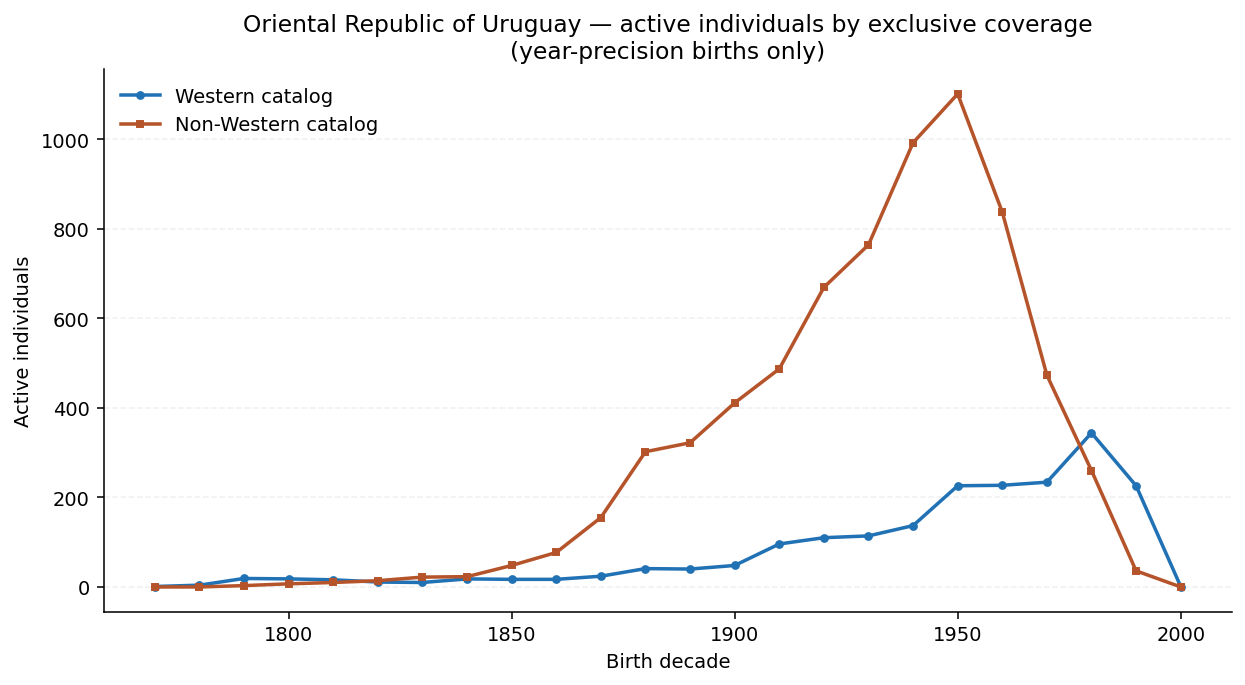


Totals — Western only: 1,999   Non-Western only: 7,013
Year-precision Uruguayans plotted: 15,438


In [4]:
df = df.with_columns(((pl.col('birth_year') // BIN_SIZE) * BIN_SIZE).alias('decade'))

dec_min = int(df['decade'].min())
dec_max = int(df['decade'].max())
decades = np.arange(dec_min, dec_max + BIN_SIZE, BIN_SIZE)

def per_decade(group_label):
    counts = (
        df.filter(pl.col('group') == group_label)
        .group_by('decade')
        .agg(pl.len().alias('n'))
    )
    by_d = dict(counts.iter_rows())
    return np.array([by_d.get(int(d), 0) for d in decades])

w  = per_decade('Western catalog')
nw = per_decade('Non-Western catalog')

fig, ax = plt.subplots()
ax.plot(decades, w, color=COLOR_W, lw=1.8, marker='o', ms=3.5,
        label='Western catalog')
ax.plot(decades, nw, color=COLOR_NW, lw=1.8, marker='s', ms=3.5,
        label='Non-Western catalog')
ax.set_xlabel('Birth decade')
ax.set_ylabel('Active individuals')
ax.set_title(f'{POLITY} — active individuals by exclusive coverage\n(year-precision births only)')
ax.grid(axis='y', alpha=0.18, ls='--')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

print(f'\nTotals — Western only: {int(w.sum()):,}   Non-Western only: {int(nw.sum()):,}')
print(f'Year-precision Uruguayans plotted: {df.height:,}')

## 4. Beyond Uruguay — four polities where the catalog signal flips

The Uruguay panel above shows non-Western catalogs revealing more individuals
than Western ones. To check that this isn't a one-off, we apply the *same*
exclusive-coverage rule to four polities that each tell a different story:

- **Japan** — strong, persistent non-Western dominance.
- **Union of Soviet Socialist Republics** — early Western lead overtaken by
  Cyrillic-language catalogs.
- **Republic of Korea** — non-Western dominance with a recent Western catch-up.
- **Republic of Turkey** — Western catalogs eventually surpass non-Western ones.

Same construction as before: Cliopatria-matched individuals with year-precision
births, plotted by birth decade and split into *Western only* / *Non-Western only*.

In [5]:
PANEL_POLITIES = [
    'Japan',
    'Union of Soviet Socialist Republics',
    'Republic of Korea',
    'Republic of Turkey',
]

# Reuse the western/non-western catalog & wiki sets classified in section 1.
conn = duckdb.connect(DB_PATH, read_only=True)
for tbl, col, vals in [('w_pids','pid', w_pid),('nw_pids','pid', nw_pid),
                       ('w_sites','site', w_sites),('nw_sites','site', nw_sites)]:
    conn.execute(f'DROP TABLE IF EXISTS temp.{tbl}')
    conn.execute(f'CREATE TEMP TABLE {tbl} ({col} TEXT PRIMARY KEY)')
    conn.executemany(f'INSERT INTO {tbl} VALUES (?)', [(v,) for v in vals])

placeholders = ','.join('?' for _ in PANEL_POLITIES)
panel = conn.execute(f"""
    WITH base AS (
        SELECT ic.wikidata_id, ic.polity_name,
               TRY_CAST(SUBSTR(i.birthdate, 1, INSTR(i.birthdate || '-', '-') - 1)
                        AS INTEGER) AS birth_year
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ic.polity_name IN ({placeholders})
          AND i.birthdate_precision >= {MIN_PRECISION}
          AND i.birthdate IS NOT NULL AND i.birthdate <> ''
    ),
    cat AS (
        SELECT i.wikidata_id,
               MAX(CASE WHEN wp.pid  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM identifiers i
        LEFT JOIN w_pids  wp  ON i.property_id = wp.pid
        LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
        WHERE i.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY i.wikidata_id
    ),
    wiki AS (
        SELECT wl.wikidata_id,
               MAX(CASE WHEN ws.site  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nws.site IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM wikimedia_links wl
        LEFT JOIN w_sites  ws  ON wl.site = ws.site
        LEFT JOIN nw_sites nws ON wl.site = nws.site
        WHERE wl.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY wl.wikidata_id
    )
    SELECT b.polity_name, b.wikidata_id, b.birth_year,
           COALESCE(GREATEST(c.w, w.w),  c.w,  w.w,  0) AS has_w,
           COALESCE(GREATEST(c.nw, w.nw),c.nw, w.nw, 0) AS has_nw
    FROM base b
    LEFT JOIN cat  c ON c.wikidata_id = b.wikidata_id
    LEFT JOIN wiki w ON w.wikidata_id = b.wikidata_id
""", PANEL_POLITIES).pl()
conn.close()

panel = (
    panel.drop_nulls(subset=['birth_year'])
    .filter((pl.col('birth_year') > 1700) & (pl.col('birth_year') <= 2025))
    .with_columns(
        pl.when((pl.col('has_w') == 1) & (pl.col('has_nw') == 0))
          .then(pl.lit('Western only'))
        .when((pl.col('has_nw') == 1) & (pl.col('has_w') == 0))
          .then(pl.lit('Non-Western only'))
        .when((pl.col('has_w') == 0) & (pl.col('has_nw') == 0))
          .then(pl.lit('none'))
        .otherwise(pl.lit('mixed'))
        .alias('group'),
        ((pl.col('birth_year') // BIN_SIZE) * BIN_SIZE).alias('decade'),
    )
)

(panel.group_by(['polity_name', 'group'])
      .agg(pl.len().alias('n'))
      .sort(['polity_name', 'n'], descending=[False, True]))

polity_name,group,n
str,str,u32
"""Japan""","""mixed""",82716
"""Japan""","""Non-Western only""",62064
"""Japan""","""Western only""",3434
"""Japan""","""none""",3069
"""Republic of Korea""","""Non-Western only""",19899
…,…,…
"""Republic of Turkey""","""Western only""",6155
"""Union of Soviet Socialist Repu…","""Non-Western only""",102811
"""Union of Soviet Socialist Repu…","""mixed""",58164


### Figure: four-polity panel — Western-only vs Non-Western-only catalog coverage

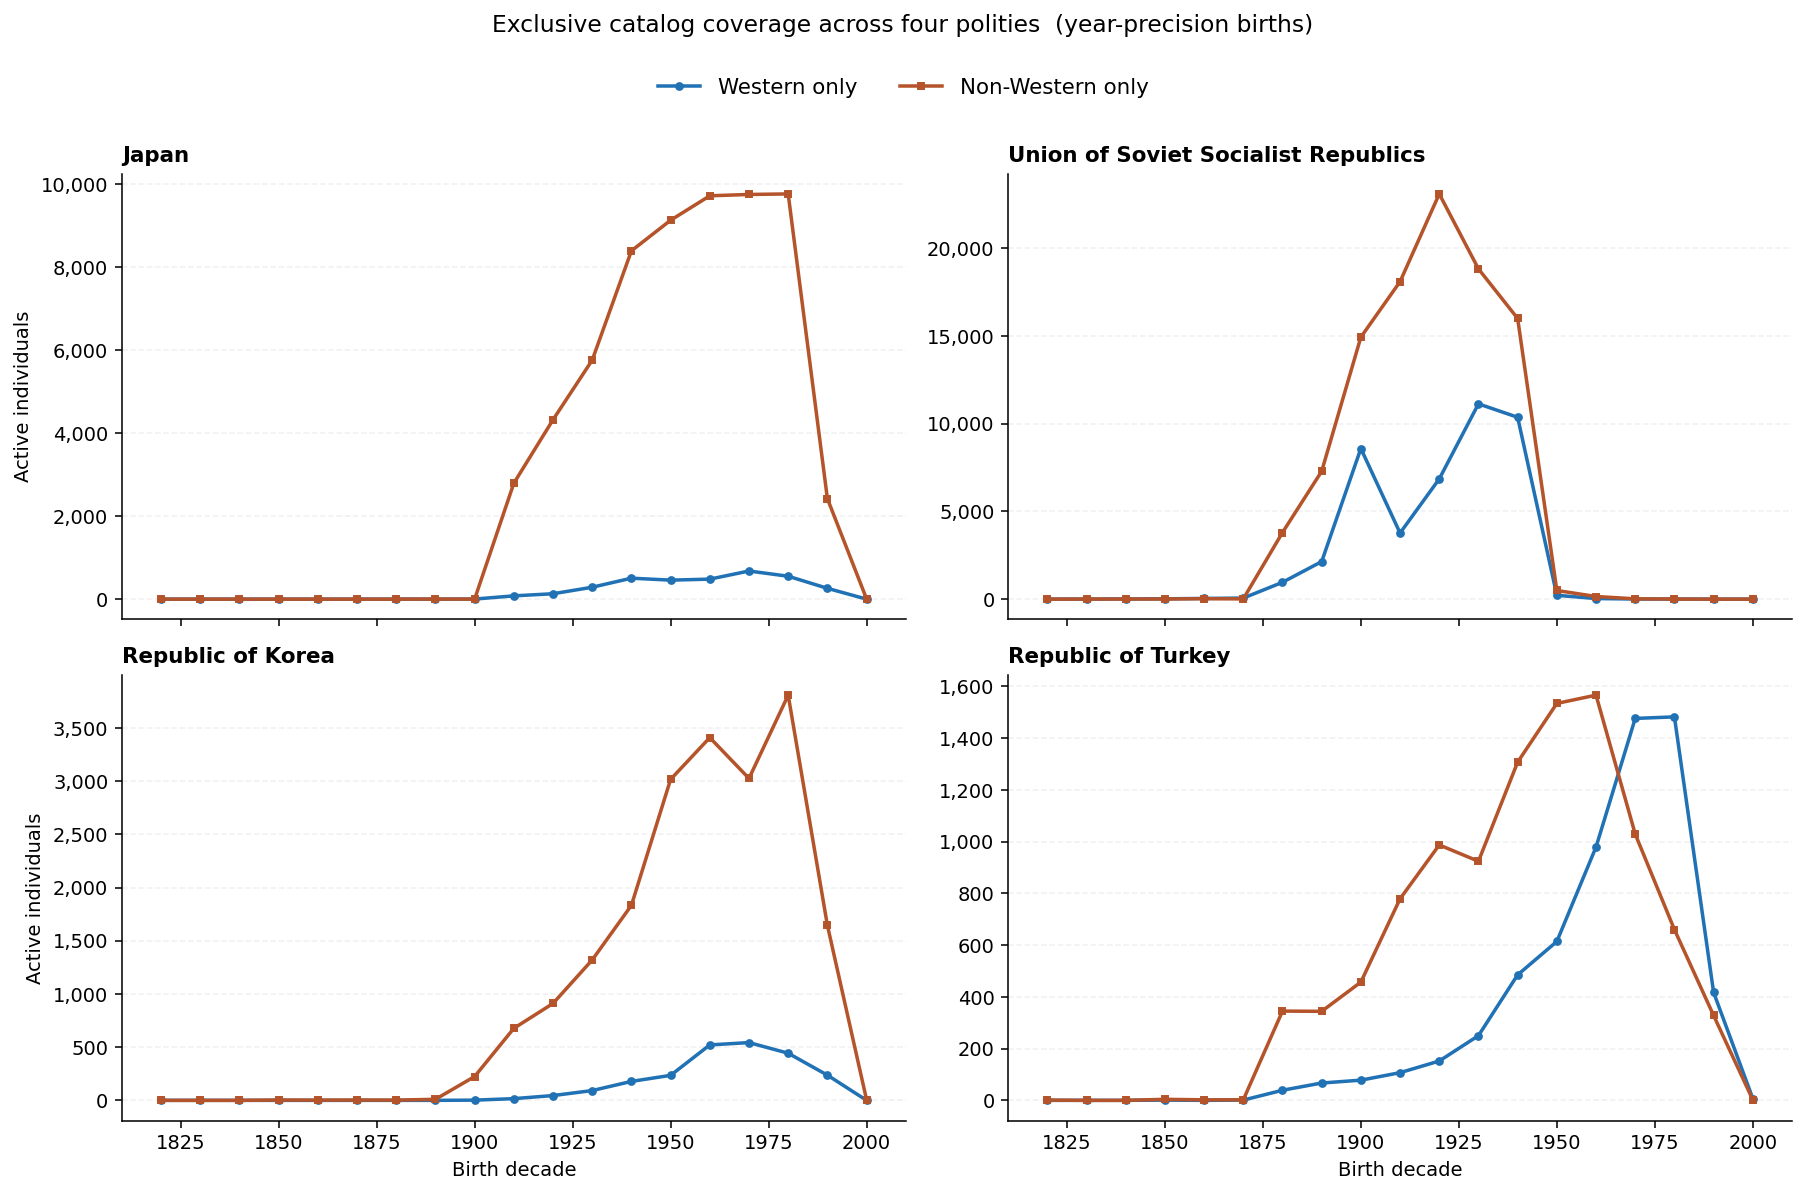


First decade where Non-Western-only first overtakes Western-only (W ≥ 10):
  Japan                                         1910
  Union of Soviet Socialist Republics           1880
  Republic of Korea                             1910
  Republic of Turkey                            1880


In [6]:
def per_decade_for(sub_df, group_label, decades):
    counts = (
        sub_df.filter(pl.col('group') == group_label)
              .group_by('decade').agg(pl.len().alias('n'))
    )
    by_d = dict(counts.iter_rows())
    return np.array([by_d.get(int(d), 0) for d in decades])

# Common decade axis across all four polities so panels are comparable.
dec_min = int(panel['decade'].min())
dec_max = int(panel['decade'].max())
panel_decades = np.arange(dec_min, dec_max + BIN_SIZE, BIN_SIZE)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, pol in zip(axes.flat, PANEL_POLITIES):
    sub = panel.filter(pl.col('polity_name') == pol)
    w_arr  = per_decade_for(sub, 'Western only',     panel_decades)
    nw_arr = per_decade_for(sub, 'Non-Western only', panel_decades)

    ax.plot(panel_decades, w_arr,  color=COLOR_W,  lw=1.8, marker='o', ms=3.5,
            label='Western only')
    ax.plot(panel_decades, nw_arr, color=COLOR_NW, lw=1.8, marker='s', ms=3.5,
            label='Non-Western only')

    # Trim to the polity's actual span to avoid long flat tails dominating the panel.
    nz = np.flatnonzero((w_arr + nw_arr) > 0)
    if nz.size:
        ax.set_xlim(panel_decades[nz[0]] - BIN_SIZE,
                    panel_decades[nz[-1]] + BIN_SIZE)

    ax.set_title(pol, fontsize=11, fontweight='bold', loc='left')
    ax.grid(axis='y', alpha=0.18, ls='--')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

for ax in axes[-1, :]:
    ax.set_xlabel('Birth decade')
for ax in axes[:, 0]:
    ax.set_ylabel('Active individuals')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2,
           frameon=False, bbox_to_anchor=(0.5, 1.02), fontsize=11)

fig.suptitle('Exclusive catalog coverage across four polities  (year-precision births)',
             y=1.06, fontsize=12)
fig.tight_layout()
plt.show()

# Crossover diagnostic — restrict to decades where the Western-only line has at least
# 10 individuals so we don't flag spurious zero-vs-zero ties before the polity exists.
print('\nFirst decade where Non-Western-only first overtakes Western-only (W ≥ 10):')
for pol in PANEL_POLITIES:
    sub = panel.filter(pl.col('polity_name') == pol)
    w_arr  = per_decade_for(sub, 'Western only',     panel_decades)
    nw_arr = per_decade_for(sub, 'Non-Western only', panel_decades)
    mask = (w_arr >= 10) & (nw_arr > w_arr)
    flip = panel_decades[mask]
    first = int(flip[0]) if flip.size else None
    label = first if first is not None else 'never (W-only always ≥ NW-only)'
    print(f'  {pol:<45} {label}')

## 5. Where do polities sit on the Western / non-Western axis?

To frame the four panels above, we rank the **top 25 polities by total
exclusive-coverage volume** (Western-only + Non-Western-only) and split each
bar by share. Polities lean Western (top of the chart) or non-Western
(bottom). The previously-discussed cases — Uruguay and the four panel
polities — are highlighted in bold.

In [7]:
conn = duckdb.connect(DB_PATH, read_only=True)
for tbl, col, vals in [('w_pids','pid', w_pid),('nw_pids','pid', nw_pid),
                       ('w_sites','site', w_sites),('nw_sites','site', nw_sites)]:
    conn.execute(f'DROP TABLE IF EXISTS temp.{tbl}')
    conn.execute(f'CREATE TEMP TABLE {tbl} ({col} TEXT PRIMARY KEY)')
    conn.executemany(f'INSERT INTO {tbl} VALUES (?)', [(v,) for v in vals])

ranking = conn.execute(f"""
    WITH base AS (
        SELECT ic.wikidata_id, ic.polity_name
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ic.polity_name IS NOT NULL AND ic.polity_name <> ''
          AND i.birthdate_precision >= {MIN_PRECISION}
          AND i.birthdate IS NOT NULL AND i.birthdate <> ''
    ),
    cat AS (
        SELECT i.wikidata_id,
               MAX(CASE WHEN wp.pid  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM identifiers i
        LEFT JOIN w_pids  wp  ON i.property_id = wp.pid
        LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
        WHERE i.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY i.wikidata_id
    ),
    wiki AS (
        SELECT wl.wikidata_id,
               MAX(CASE WHEN ws.site  IS NOT NULL THEN 1 ELSE 0 END) AS w,
               MAX(CASE WHEN nws.site IS NOT NULL THEN 1 ELSE 0 END) AS nw
        FROM wikimedia_links wl
        LEFT JOIN w_sites  ws  ON wl.site = ws.site
        LEFT JOIN nw_sites nws ON wl.site = nws.site
        WHERE wl.wikidata_id IN (SELECT wikidata_id FROM base)
        GROUP BY wl.wikidata_id
    ),
    flags AS (
        SELECT b.polity_name,
               COALESCE(GREATEST(c.w, w.w),  c.w,  w.w,  0) AS has_w,
               COALESCE(GREATEST(c.nw, w.nw),c.nw, w.nw, 0) AS has_nw
        FROM base b
        LEFT JOIN cat  c ON c.wikidata_id = b.wikidata_id
        LEFT JOIN wiki w ON w.wikidata_id = b.wikidata_id
    )
    SELECT polity_name,
           CAST(SUM(CASE WHEN has_w  = 1 AND has_nw = 0 THEN 1 ELSE 0 END) AS BIGINT) AS w_only,
           CAST(SUM(CASE WHEN has_nw = 1 AND has_w  = 0 THEN 1 ELSE 0 END) AS BIGINT) AS nw_only
    FROM flags
    GROUP BY polity_name
""").pl()
conn.close()

ranking = (
    ranking.with_columns((pl.col('w_only') + pl.col('nw_only')).alias('exclusive'))
           .filter(pl.col('exclusive') >= 500)
           .with_columns(
               (pl.col('w_only').cast(pl.Float64)  / pl.col('exclusive')).alias('share_w'),
               (pl.col('nw_only').cast(pl.Float64) / pl.col('exclusive')).alias('share_nw'),
           )
           .sort('exclusive', descending=True)
           .head(25)
           .sort('share_nw')
)
ranking.head()

polity_name,w_only,nw_only,exclusive,share_w,share_nw
str,i64,i64,i64,f64,f64
"""Kingdom of Sweden""",53375,91,53466,0.998298,0.001702
"""Kingdom of Norway""",35121,64,35185,0.998181,0.001819
"""Republic of Finland""",34280,100,34380,0.997091,0.002909
"""Kingdom of Spain""",67681,218,67899,0.996789,0.003211
"""Federated Republic of Germany""",97203,322,97525,0.996698,0.003302


### Figure: 25 polities ranked by Western / non-Western share of exclusive coverage

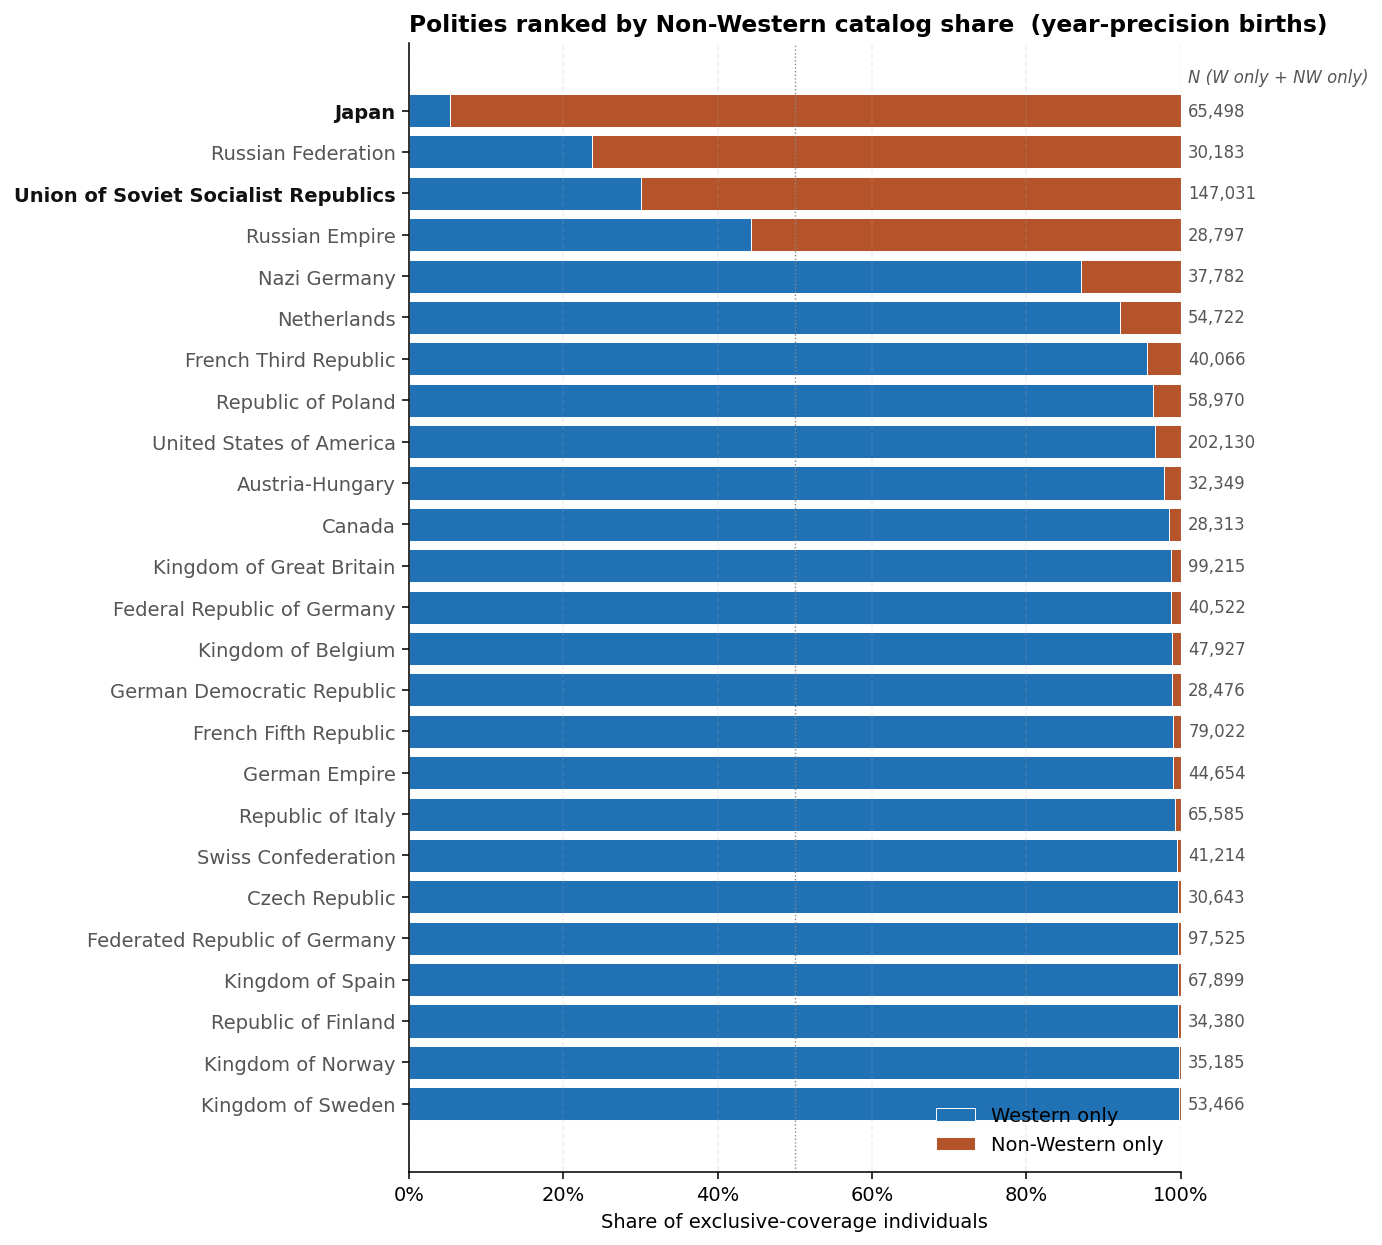

In [8]:
HIGHLIGHT = set(PANEL_POLITIES) | {POLITY}

labels  = ranking['polity_name'].to_list()
share_w = ranking['share_w'].to_numpy()
share_n = ranking['share_nw'].to_numpy()
totals  = ranking['exclusive'].to_list()
y       = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(y, share_w, color=COLOR_W,  edgecolor='white', linewidth=0.5,
        label='Western only')
ax.barh(y, share_n, left=share_w, color=COLOR_NW, edgecolor='white', linewidth=0.5,
        label='Non-Western only')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
for tick, lab in zip(ax.get_yticklabels(), labels):
    if lab in HIGHLIGHT:
        tick.set_fontweight('bold')
        tick.set_color('#111111')
    else:
        tick.set_color('#555555')

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_xlabel('Share of exclusive-coverage individuals')
ax.axvline(0.5, color='#888', lw=0.7, ls=':')
ax.grid(axis='x', alpha=0.18, ls='--')

# Total volume annotation on the right edge
for yi, t in zip(y, totals):
    ax.text(1.01, yi, f'{int(t):,}', va='center', ha='left',
            fontsize=8.5, color='#555')
ax.text(1.01, len(labels) - 0.4, 'N (W only + NW only)',
        va='bottom', ha='left', fontsize=8.5, color='#555', style='italic')

ax.legend(loc='lower right', frameon=False, fontsize=10)
ax.set_title('Polities ranked by Non-Western catalog share  '
             '(year-precision births)',
             loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()